<a href="https://colab.research.google.com/github/sayak395/Jaynes-Cummings-model/blob/main/Parameterisation_of_JC_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qutip

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from qutip import (basis, destroy, mesolve, qeye, tensor, create, sigmaz, sigmam, sigmap, fock, Qobj, fidelity, Options)
from scipy.signal import find_peaks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 58.5 MB/s eta 0:00:00


In [2]:
# Hilbert space dimension for the cavity
n_cavity = 10
sigma_z_np = np.array([[1 , 0],
                   [0, -1]])
sigma_z_alt = Qobj(sigma_z_np)
sigma_plus_np = np.array([[0, 1],
                   [0, 0]])
sigma_plus_alt = Qobj(sigma_plus_np)
sigma_minus_np = np.transpose(sigma_plus_np)
sigma_minus_alt = Qobj(sigma_minus_np)

In [3]:
###########################
# Define the Operators
###########################

sigma_minus = tensor(qeye(n_cavity), sigma_minus_alt) # atomic lowering operator
sigma_plus =  tensor(qeye(n_cavity), sigma_plus_alt)  # atomic raising operator
sigma_z = tensor(qeye(n_cavity), sigma_z_alt)     # atomic z operator
a = tensor(destroy(n_cavity), qeye(2))   # cavity annihilation operator
spin_down = fock(2, 1)
spin_up = fock(2, 0)

In [4]:
wc = wa = 1.0  # Example values
w0 = wc # resonance driving
delta_c = (wc - w0)/wc
delta_a = (wa - w0)/wc
g = 0.01 * wc

In [5]:
psi = tensor(fock(n_cavity, 0), spin_down)
psi_den = psi * psi.dag()
target_state = tensor(fock(n_cavity, 1), spin_down)
target_den = target_state * target_state.dag()

In [6]:
from scipy.interpolate import CubicSpline
!pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.plots import plot_convergence
from skopt.utils import use_named_args

from skopt.plots import plot_convergence, plot_objective, plot_evaluations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.0 MB/s eta 0:00:00


We are now parameterising the system with one point in the middle and optimising. Later on we can implement the optimal x time for the new point too.

^ The previous one didn't work almost 0 fidelity.

So now in this one we are using three points and allowing the amplitude to go negative as well.

In [7]:
def f_t(t, args):

  frequency = args['frequencies']
  envelope_func = args['spline']

  #return envelope_func(t) * np.cos(2 * g * np.sqrt(1) * t)

  return envelope_func(t) * np.cos(frequency * t)




In [8]:
def objective_general(frequency, envelope_y_value, envelope_x_value, Y2, X2, Y3, X3, sim_time):

    if (envelope_x_value >= sim_time) or (envelope_x_value <= 0):
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X2 >= sim_time or X2 <= 0:
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X2 <= envelope_x_value:
        return float('0')  # Penalise if envelope_x_value is not in order

    elif X3 >= sim_time or X3 <= 0:
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X3 <= X2:
        return float('0')  # Penalise if envelope_x_value is not in order

    elif X3 <= envelope_x_value:
        return float('0')  # Penalise if envelope_x_value is not in order


    envelope_values = [0, envelope_y_value, Y2, Y3, 0]
    control_times = [0, envelope_x_value, X2, X3, sim_time]

    # Create a cubic spline for the envelope function
    spline = CubicSpline(control_times, envelope_values, extrapolate=False)

    args = {
        'frequencies': frequency,
        'spline': spline,
        'sim_time': sim_time
    }

    tau = wc * sim_time  # Time array for simulation

    H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
    H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]

    H = [H_static, H_drive]

    result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[], options={'nsteps': 1e9, 'atol': 1e-7, 'rtol': 1e-7}, args=args)
    final_rho = result.states[-1]
    fid = fidelity(final_rho, target_den)
    return -fid  # Minimise negative fidelity

def objective(x):
    return objective_general(x[0], x[1], x[2], x[3], x[4], x[5], x[6], x[-1])


# Define the parameter space for Bayesian Optimisation
space = [Real(0.0, 1.0, name='frequency'),
         Real(-g, g, name='envelope_y_value'),
         Real(0, 3000, name='envelope_x_value'),
         Real(-g, g, name='Y2'),
         Real(0, 3000, name='X2'),
         Real(-g, g, name='Y3'),
         Real(0, 3000, name='X3'),
         Real(0, 3000, name='sim_time')]

# Perform Bayesian Optimisation
res = gp_minimize(objective, space, n_calls=200, random_state=42, verbose=True, acq_func='EI')

# Print the best parameters found
print(f"Optimal frequency: {res.x[0]:.2f}, Optimal simulation time: {res.x[-1]:.2f}")

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0016
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 6 started. Evaluating

In [9]:
print("Optimal envelope parameters:")
print(f"  Y1: {res.x[1]:.2f}, X1: {res.x[2]:.2f}")
print(f"  Y2: {res.x[3]:.2f}, X2: {res.x[4]:.2f}")
print(f"  Y3: {res.x[5]:.2f}, X3: {res.x[6]:.2f}")

Optimal envelope parameters:
  Y1: -0.01, X1: 95.05
  Y2: -0.01, X2: 1378.84
  Y3: 0.01, X3: 1977.75


In [10]:
# Check what frequency is used

freq = 2 * g * np.sqrt(1)
print(freq/(res.x[0] * wc))

0.5169481803181074


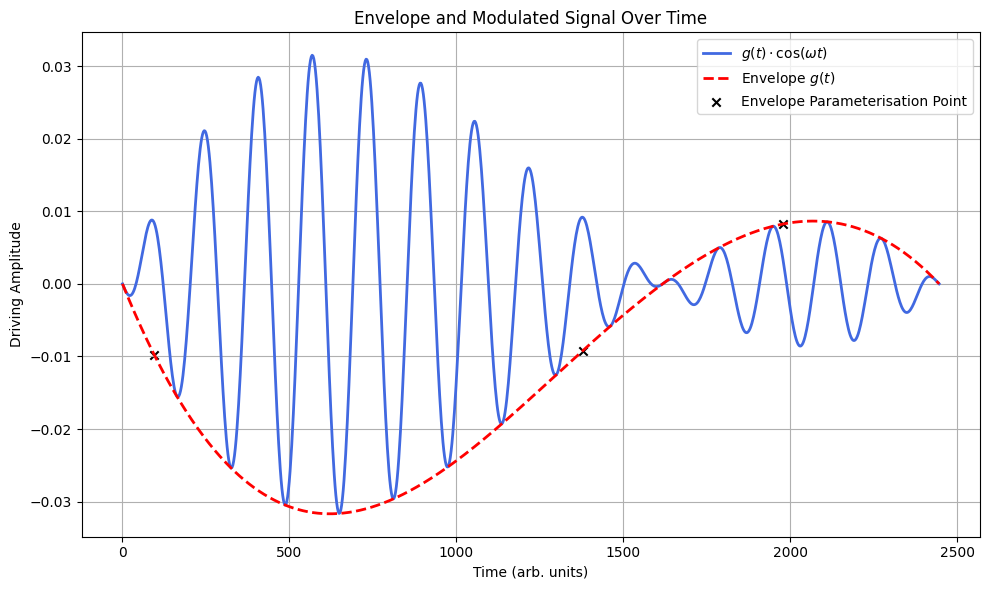

In [11]:
# Assuming 'res' holds the results from Bayesian optimization and contains optimal values
optimal_frequency = res.x[0]
optimal_envelope_value = res.x[1]
optimal_envelope_x_value = res.x[2]
optimal_Y2 = res.x[3]
optimal_X2 = res.x[4]
optimal_Y3 = res.x[5]
optimal_X3 = res.x[6]
optimal_sim_time = res.x[-1]

# Define the envelope function using optimal parameters
envelope_values = [0, optimal_envelope_value, optimal_Y2, optimal_Y3, 0]
control_times = [0, optimal_envelope_x_value, optimal_X2, optimal_X3, optimal_sim_time]
spline = CubicSpline(control_times, envelope_values, extrapolate=False)

# Time array for the simulation, using the optimal simulation time
tau = np.linspace(0, optimal_sim_time, 1000)

envelope = spline(tau)
cosine_wave = np.cos(optimal_frequency * tau)
modulated_wave = envelope * cosine_wave

# Plotting the envelope and the modulated signal
plt.figure(figsize=(10, 6))

plt.plot(tau, modulated_wave, label='$g(t) \\cdot \\cos(\\omega t)$', linewidth=2, color ='royalblue')
plt.plot(tau, envelope, label='Envelope $g(t)$', linestyle='--',color='red', linewidth=2)
plt.scatter(control_times[1:4], envelope_values[1:4], marker = 'x', color = 'black', label = 'Envelope Parameterisation Point')
plt.title('Envelope and Modulated Signal Over Time')
plt.xlabel('Time (arb. units)')
plt.ylabel('Driving Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

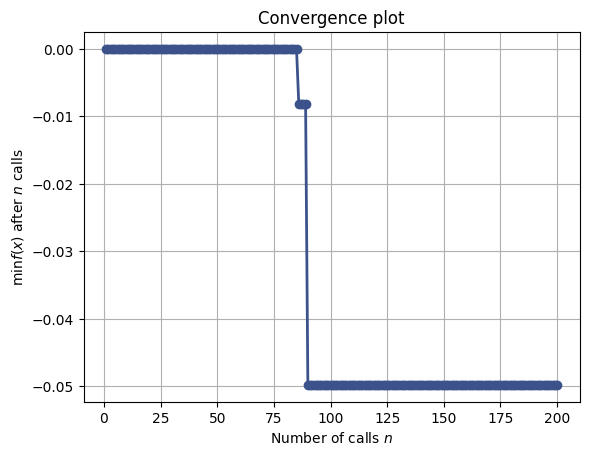

In [12]:
plot_convergence(res)
plt.show()

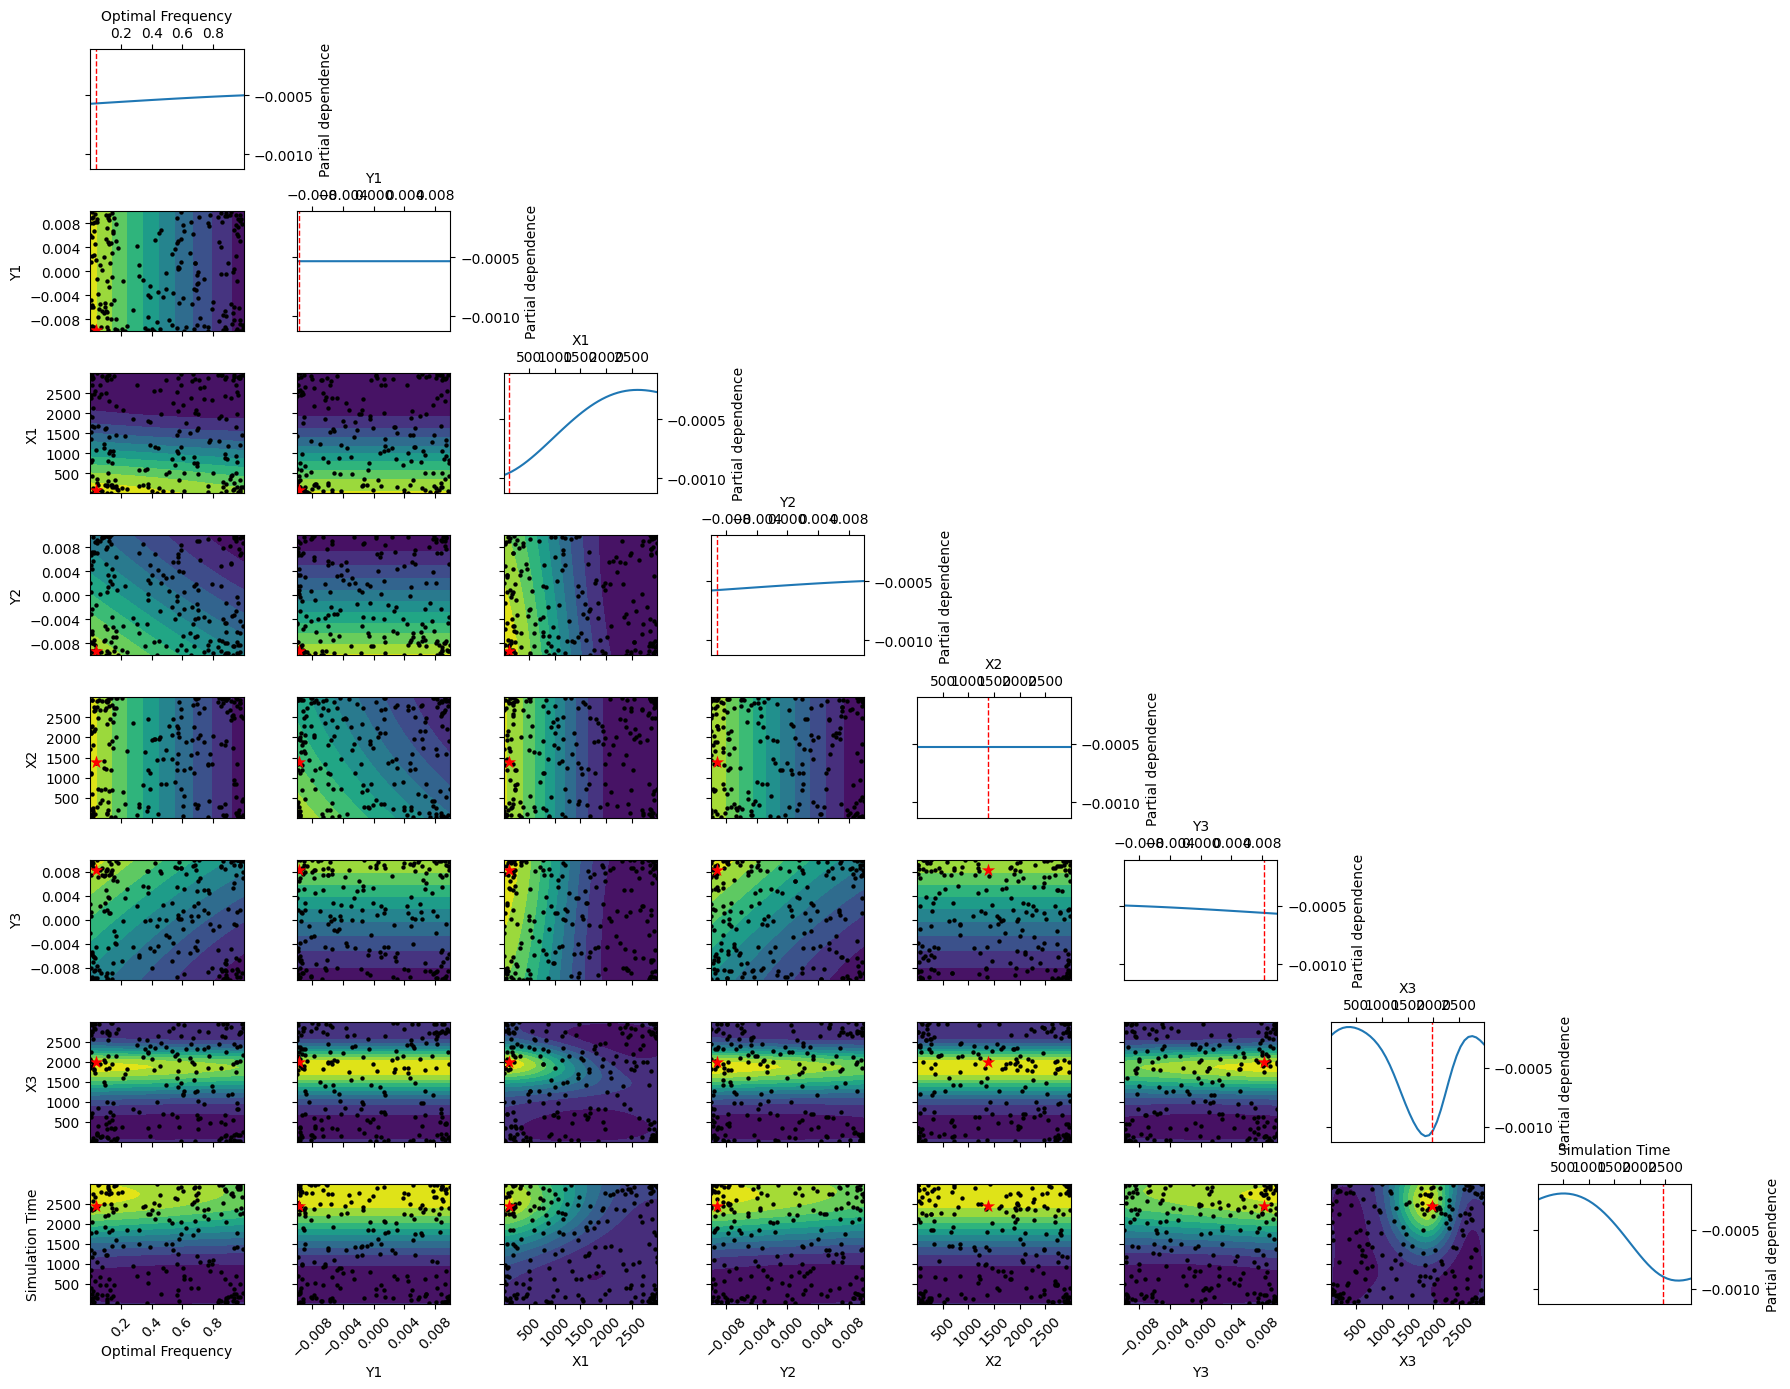

In [13]:
fig, ax = plt.subplots(figsize=(18, 14))  # You can adjust the dimensions as needed
plot_objective(res, dimensions=['Optimal Frequency', 'Y1', 'X1', 'Y2', 'X2', 'Y3', 'X3', 'Simulation Time'], ax=ax)
plt.tight_layout()
plt.show()

**Plotting the dynamics of the system so we can understand why the fidelity is not reaching higher and higher values.**

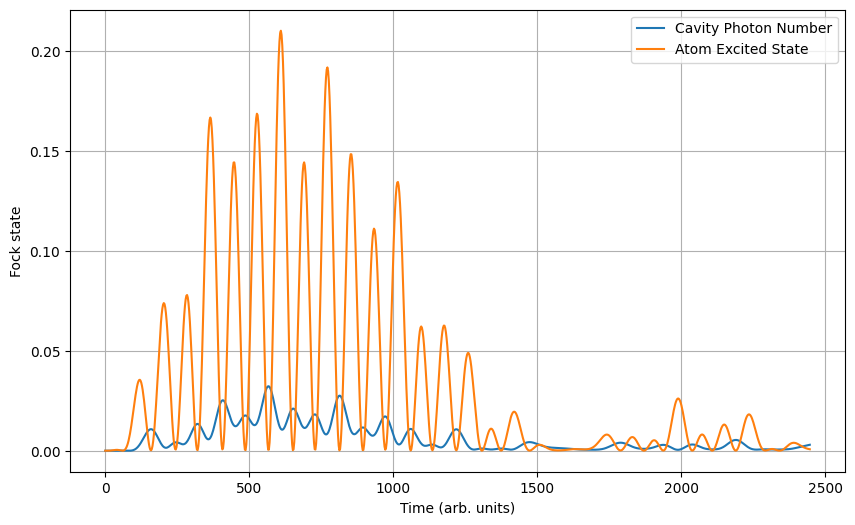

In [14]:
psi = tensor(fock(n_cavity, 0), spin_down)

args = {'frequencies': optimal_frequency, 'spline': spline}

# Time-dependent driving term
H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
H = [H_static, H_drive]

output = mesolve(H, psi, tau, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)

n_c = output.expect[0]
n_a = output.expect[1]


plt.figure(figsize=(10,6))
plt.plot(tau, n_c, label = 'Cavity Photon Number')
plt.plot(tau, n_a, label = 'Atom Excited State')
plt.grid(True)
plt.xlabel('Time (arb. units)')
plt.ylabel('Fock state')
plt.legend(loc='best')
plt.show()

# New parameterisation

Reverting back to 2 points for the parameterisation because the Bayesian Optimisation worked the best with this parameterisation. It should be noted
that the frequency is not the bare frequency of the atom. The Bayesian optimisation does not prefer this method.

In [15]:
def objective_general(frequency, envelope_y_value, envelope_x_value, Y2, X2, sim_time):

    if (envelope_x_value >= sim_time) or (envelope_x_value <= 0):
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X2 >= sim_time or X2 <= 0:
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X2 <= envelope_x_value:
        return float('0')  # Penalise if envelope_x_value is not in order

    envelope_values = [0, envelope_y_value, Y2, 0]
    control_times = [0, envelope_x_value, X2, sim_time]

    # Create a cubic spline for the envelope function
    spline = CubicSpline(control_times, envelope_values, extrapolate=False)

    args = {
        'frequencies': frequency,
        'spline': spline,
        'sim_time': sim_time
    }

    tau = wc * sim_time  # Time array for simulation

    H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
    H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t(t, args)]

    H = [H_static, H_drive]

    result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[], options={'nsteps': 1e9, 'atol': 1e-7, 'rtol': 1e-7}, args=args)
    final_rho = result.states[-1]
    fid = fidelity(final_rho, target_den)
    return -fid  # Minimise negative fidelity

def objective(x):
    return objective_general(x[0], x[1], x[2], x[3], x[4], x[-1])


# Define the parameter space for Bayesian Optimisation
space = [Real(0.0, 1.0, name='frequency'),
         Real(-g, g, name='envelope_y_value'),
         Real(0, 3000, name='envelope_x_value'),
         Real(-g, g, name='Y2'),
         Real(0, 3000, name='X2'),
         Real(0, 3000, name='sim_time')]

# Perform Bayesian Optimisation
res = gp_minimize(objective, space, n_calls=200, random_state=42, verbose=True, acq_func='EI')

# Print the best parameters found
print(f"Optimal frequency: {res.x[0]:.2f}, Optimal simulation time: {res.x[-1]:.2f}")

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0012
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0012
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0009
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 0.0009
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 3.7842
Function value obtained: -0.0026
Current minimum: -0.0026
Iteration No: 6 started. Evaluati

In [29]:
# Assuming 'res' holds the results from Bayesian optimization and contains optimal values
optimal_frequency = res.x[0]
optimal_envelope_value = res.x[1]
optimal_envelope_x_value = res.x[2]
optimal_Y2 = res.x[3]
optimal_X2 = res.x[4]
optimal_sim_time = res.x[-1]

# Define the envelope function using optimal parameters
envelope_values = [0, optimal_envelope_value, optimal_Y2, 0]
control_times = [0, optimal_envelope_x_value, optimal_X2, optimal_sim_time]
spline = CubicSpline(control_times, envelope_values, extrapolate=False)

# Time array for the simulation, using the optimal simulation time
tau = np.linspace(0, optimal_sim_time, 1000)

envelope = spline(tau)
cosine_wave = np.cos(optimal_frequency * tau)
modulated_wave = envelope * cosine_wave

# Plotting the envelope and the modulated signal
plt.figure(figsize=(10, 6))
plt.plot(tau, modulated_wave, label='$g(t) \\cdot \\cos(\\omega t)$', linewidth=2, color ='royalblue')
plt.plot(tau, envelope, label='Envelope $g(t)$', linestyle='--',color='red', linewidth=2)
plt.scatter(control_times[1:3], envelope_values[1:3], marker = 'x', color = 'black', label = 'Envelope Parameterisation Point')
plt.title('Envelope and Modulated Signal Over Time')
plt.xlabel('Time (arb. units)')
plt.ylabel('Driving Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: `x` must be strictly increasing sequence.

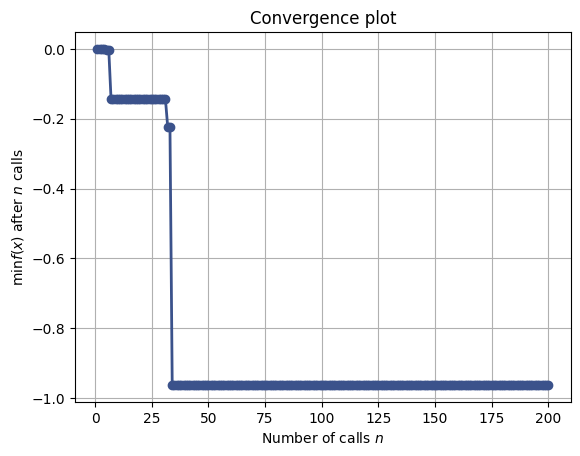

In [17]:
plot_convergence(res)
plt.show()

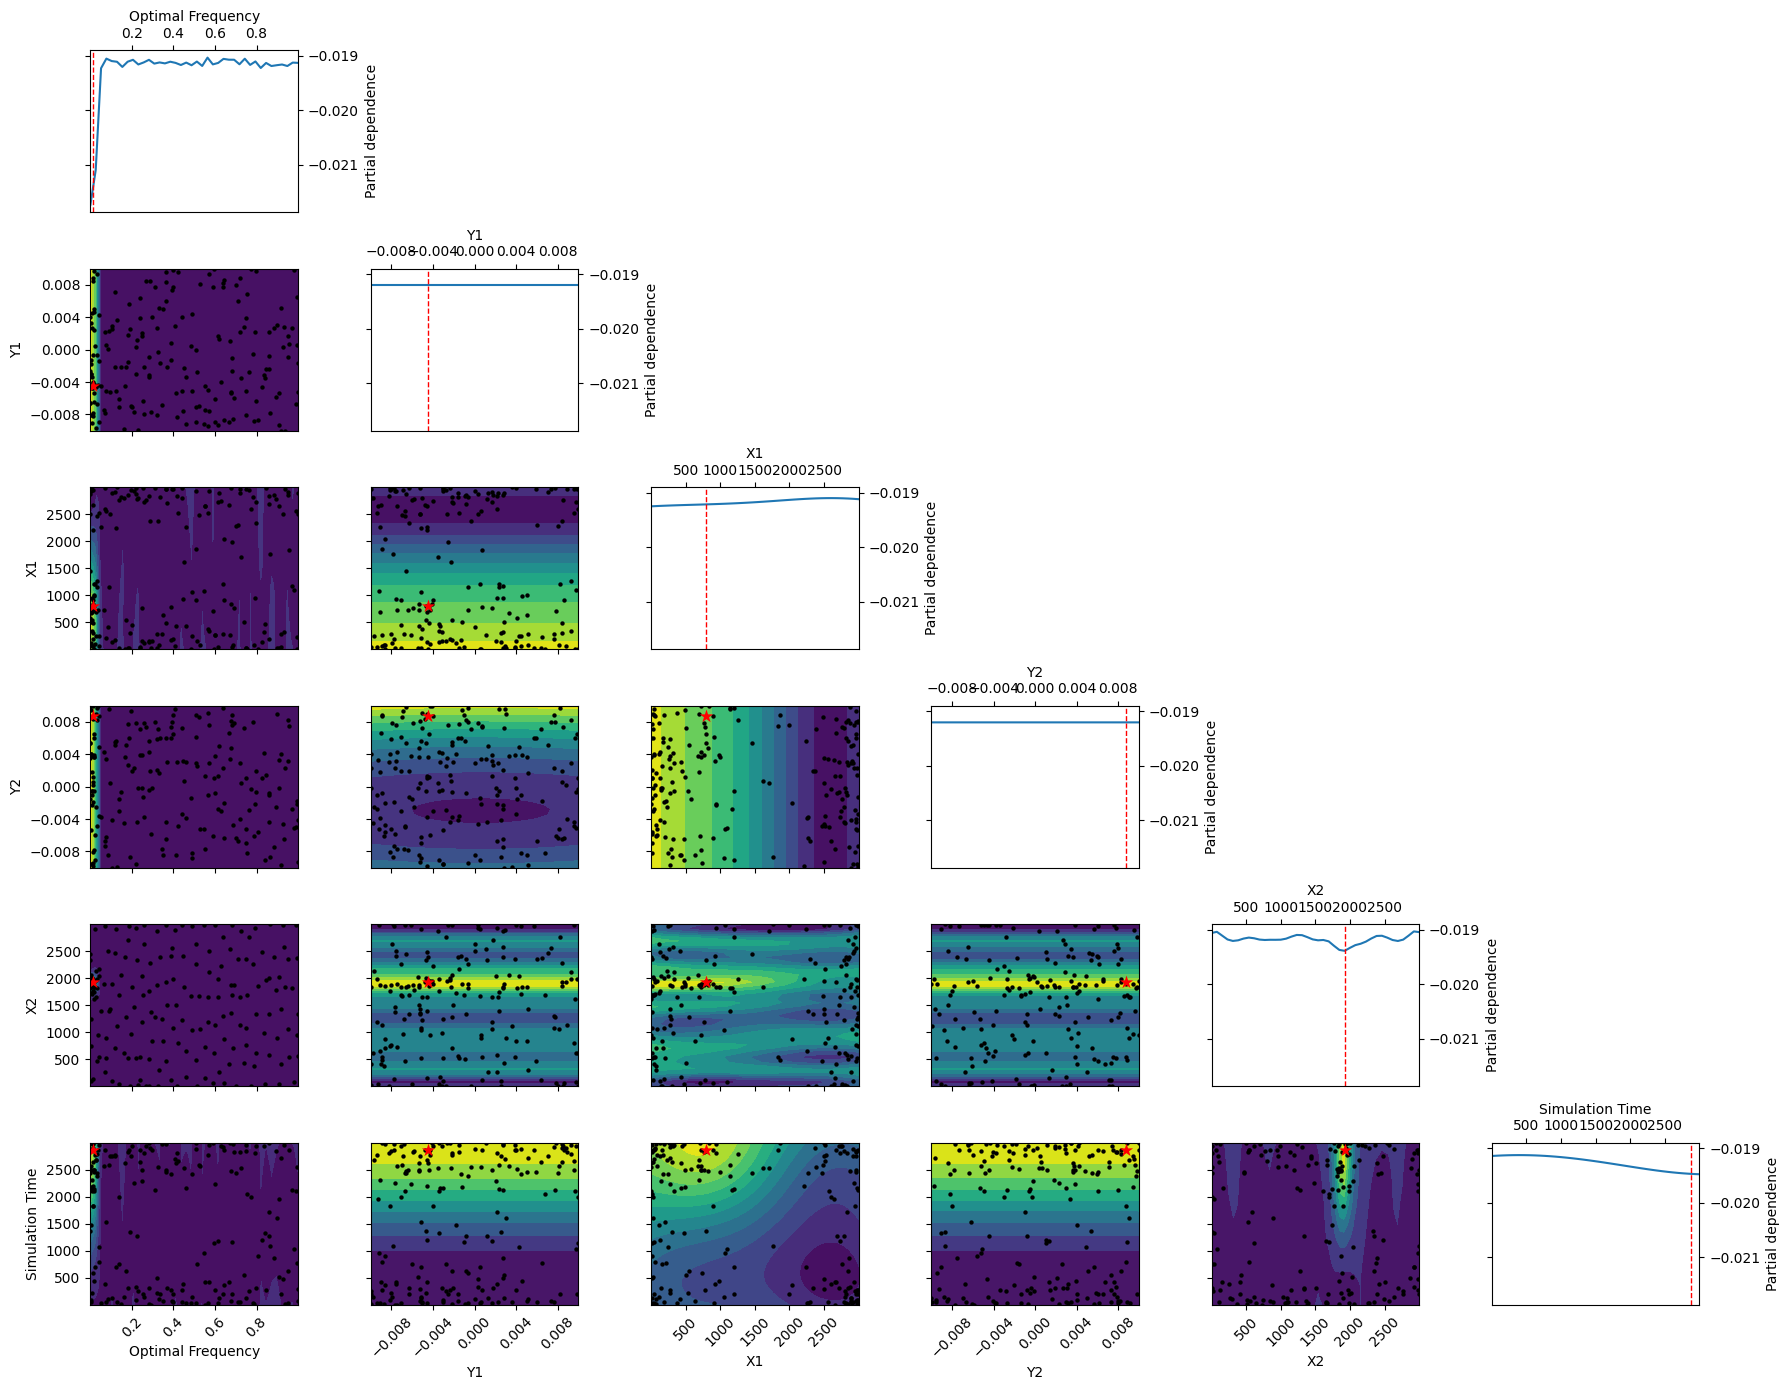

In [18]:
fig, ax = plt.subplots(figsize=(18, 14))  # You can adjust the dimensions as needed
plot_objective(res, dimensions=['Optimal Frequency', 'Y1', 'X1', 'Y2', 'X2', 'Simulation Time'], ax=ax)
plt.tight_layout()
plt.show()

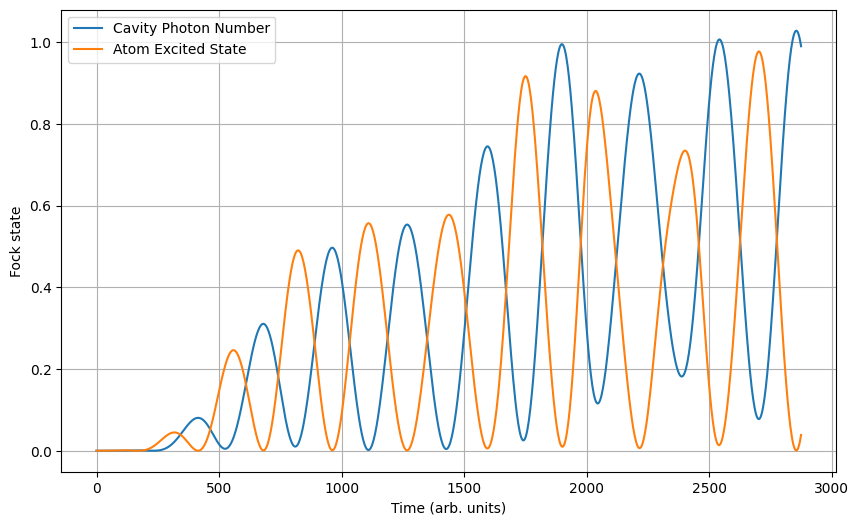

In [19]:
psi = tensor(fock(n_cavity, 0), spin_down)

args = {'frequencies': optimal_frequency, 'spline': spline}

# Time-dependent driving term
H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t(t, args)]
H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
H = [H_static, H_drive]

output = mesolve(H, psi, tau, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)

n_c = output.expect[0]
n_a = output.expect[1]


plt.figure(figsize=(10,6))
plt.plot(tau, n_c, label = 'Cavity Photon Number')
plt.plot(tau, n_a, label = 'Atom Excited State')
plt.grid(True)
plt.xlabel('Time (arb. units)')
plt.ylabel('Fock state')
plt.legend(loc='best')
plt.show()

In [25]:
frequency_bare = 2 * g * np.sqrt(1)
print(f'The bare frequency is {frequency_bare:.3f}')
print(f'The driven frequency is {res.x[0]:.3f}')

The bare frequency is 0.020
The driven frequency is 0.013


# Adjusting number of cosine terms

Now that the two point parameterisation works well. Thus, we can adjust the number of cosine terms to determine whether additional frequencies will improve the driving parameter. The frequency can be fixed at this point as well to determine if the Bayesian Optimisation does a better job at determining the optimal parameters.

In [40]:
def f_t_alt(t, args):

  frequency = args['frequencies']
  F2 = args['f2']
  envelope_func = args['spline']

  #return envelope_func(t) * np.cos(2 * g * np.sqrt(1) * t)

  return envelope_func(t) * (np.cos(frequency * t) + np.sin(F2 * t))




In [41]:
def objective_general(frequency, F2, envelope_y_value, envelope_x_value, Y2, X2, sim_time):

    if (envelope_x_value >= sim_time) or (envelope_x_value <= 0):
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X2 >= sim_time or X2 <= 0:
        return float('0')  # Penalise if envelope_x_value is out of bounds

    elif X2 <= envelope_x_value:
        return float('0')  # Penalise if envelope_x_value is not in order

    envelope_values = [0, envelope_y_value, Y2, 0]
    control_times = [0, envelope_x_value, X2, sim_time]

    # Create a cubic spline for the envelope function
    spline = CubicSpline(control_times, envelope_values, extrapolate=False)

    args = {
        'frequencies': frequency,
        'f2': F2,
        'spline': spline,
        'sim_time': sim_time
    }

    tau = wc * sim_time  # Time array for simulation

    H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
    H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t: f_t_alt(t, args)]

    H = [H_static, H_drive]

    result = mesolve(H, psi_den, [0, tau], c_ops=[], e_ops=[], options={'nsteps': 1e9, 'atol': 1e-7, 'rtol': 1e-7}, args=args)
    final_rho = result.states[-1]
    fid = fidelity(final_rho, target_den)
    return -fid  # Minimise negative fidelity

def objective(x):
    return objective_general(x[0], x[1], x[2], x[3], x[4], x[5], x[-1])


# Define the parameter space for Bayesian Optimisation
space = [Real(0.0, 1.0, name='frequency'),
         Real(0.0, 1.0, name='F2'),
         Real(-g, g, name='envelope_y_value'),
         Real(0, 3000, name='envelope_x_value'),
         Real(-g, g, name='Y2'),
         Real(0, 3000, name='X2'),
         Real(0, 3000, name='sim_time')]

# Perform Bayesian Optimisation
res_alt = gp_minimize(objective, space, n_calls=200, random_state=42, verbose=True, acq_func='EI')

# Print the best parameters found
print(f"Optimal frequency: {res_alt.x[0]:.2f}, Optimal simulation time: {res_alt.x[-1]:.2f}")

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 0.0015
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: 0.0000
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 4.2586
Function value obtained: -0.0046
Current minimum: -0.0046
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 0.0011
Function value obtained: 0.0000
Current minimum: -0.0046
Iteration No: 6 started. Evaluat

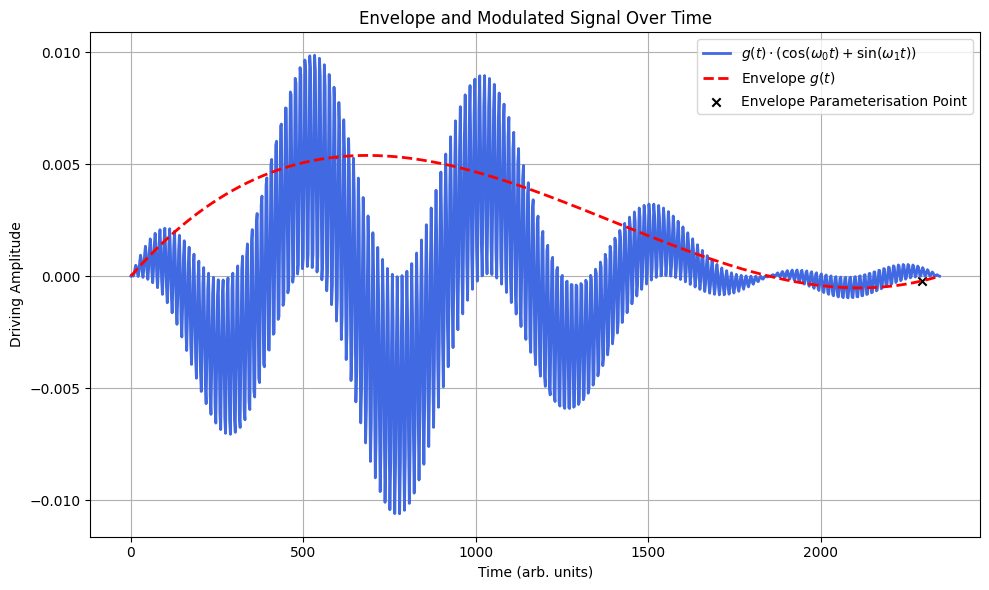

In [51]:
# Assuming 'res' holds the results from Bayesian optimization and contains optimal values
optimal_frequency = res_alt.x[0]
optimal_F2 = res_alt.x[1]
optimal_envelope_value = res_alt.x[2]
optimal_envelope_x_value = res_alt.x[3]
optimal_Y2 = res_alt.x[4]
optimal_X2 = res_alt.x[5]
optimal_sim_time = res_alt.x[-1]

# Define the envelope function using optimal parameters
envelope_values = [0, optimal_envelope_value, optimal_Y2, 0]
control_times = [0, optimal_envelope_x_value, optimal_X2, optimal_sim_time]
spline = CubicSpline(control_times, envelope_values, extrapolate=False)

# Time array for the simulation, using the optimal simulation time
tau = np.linspace(0, optimal_sim_time, 1000)

envelope = spline(tau)
cosine_wave = np.cos(optimal_frequency * tau) + np.cos(optimal_F2 * tau)
modulated_wave = envelope * cosine_wave

# Plotting the envelope and the modulated signal
plt.figure(figsize=(10, 6))
plt.plot(tau, modulated_wave, label='$g(t) \\cdot (\\cos(\\omega_{0} t) + \\sin(\\omega_{1} t) ) $', linewidth=2, color ='royalblue')
plt.plot(tau, envelope, label='Envelope $g(t)$', linestyle='--',color='red', linewidth=2)
plt.scatter(control_times[1:3], envelope_values[1:3], marker = 'x', color = 'black', label = 'Envelope Parameterisation Point')
plt.title('Envelope and Modulated Signal Over Time')
plt.xlabel('Time (arb. units)')
plt.ylabel('Driving Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

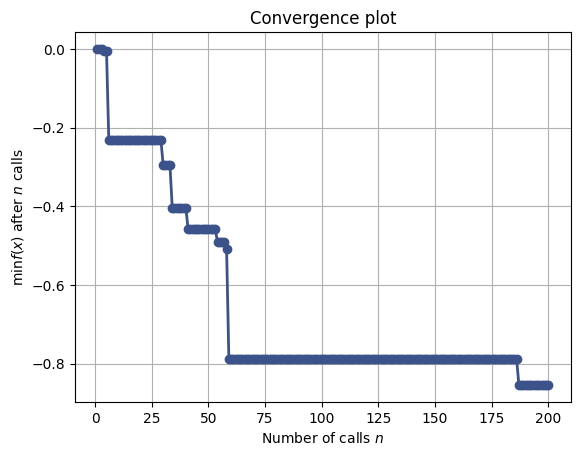

In [43]:
plot_convergence(res_alt)
plt.show()

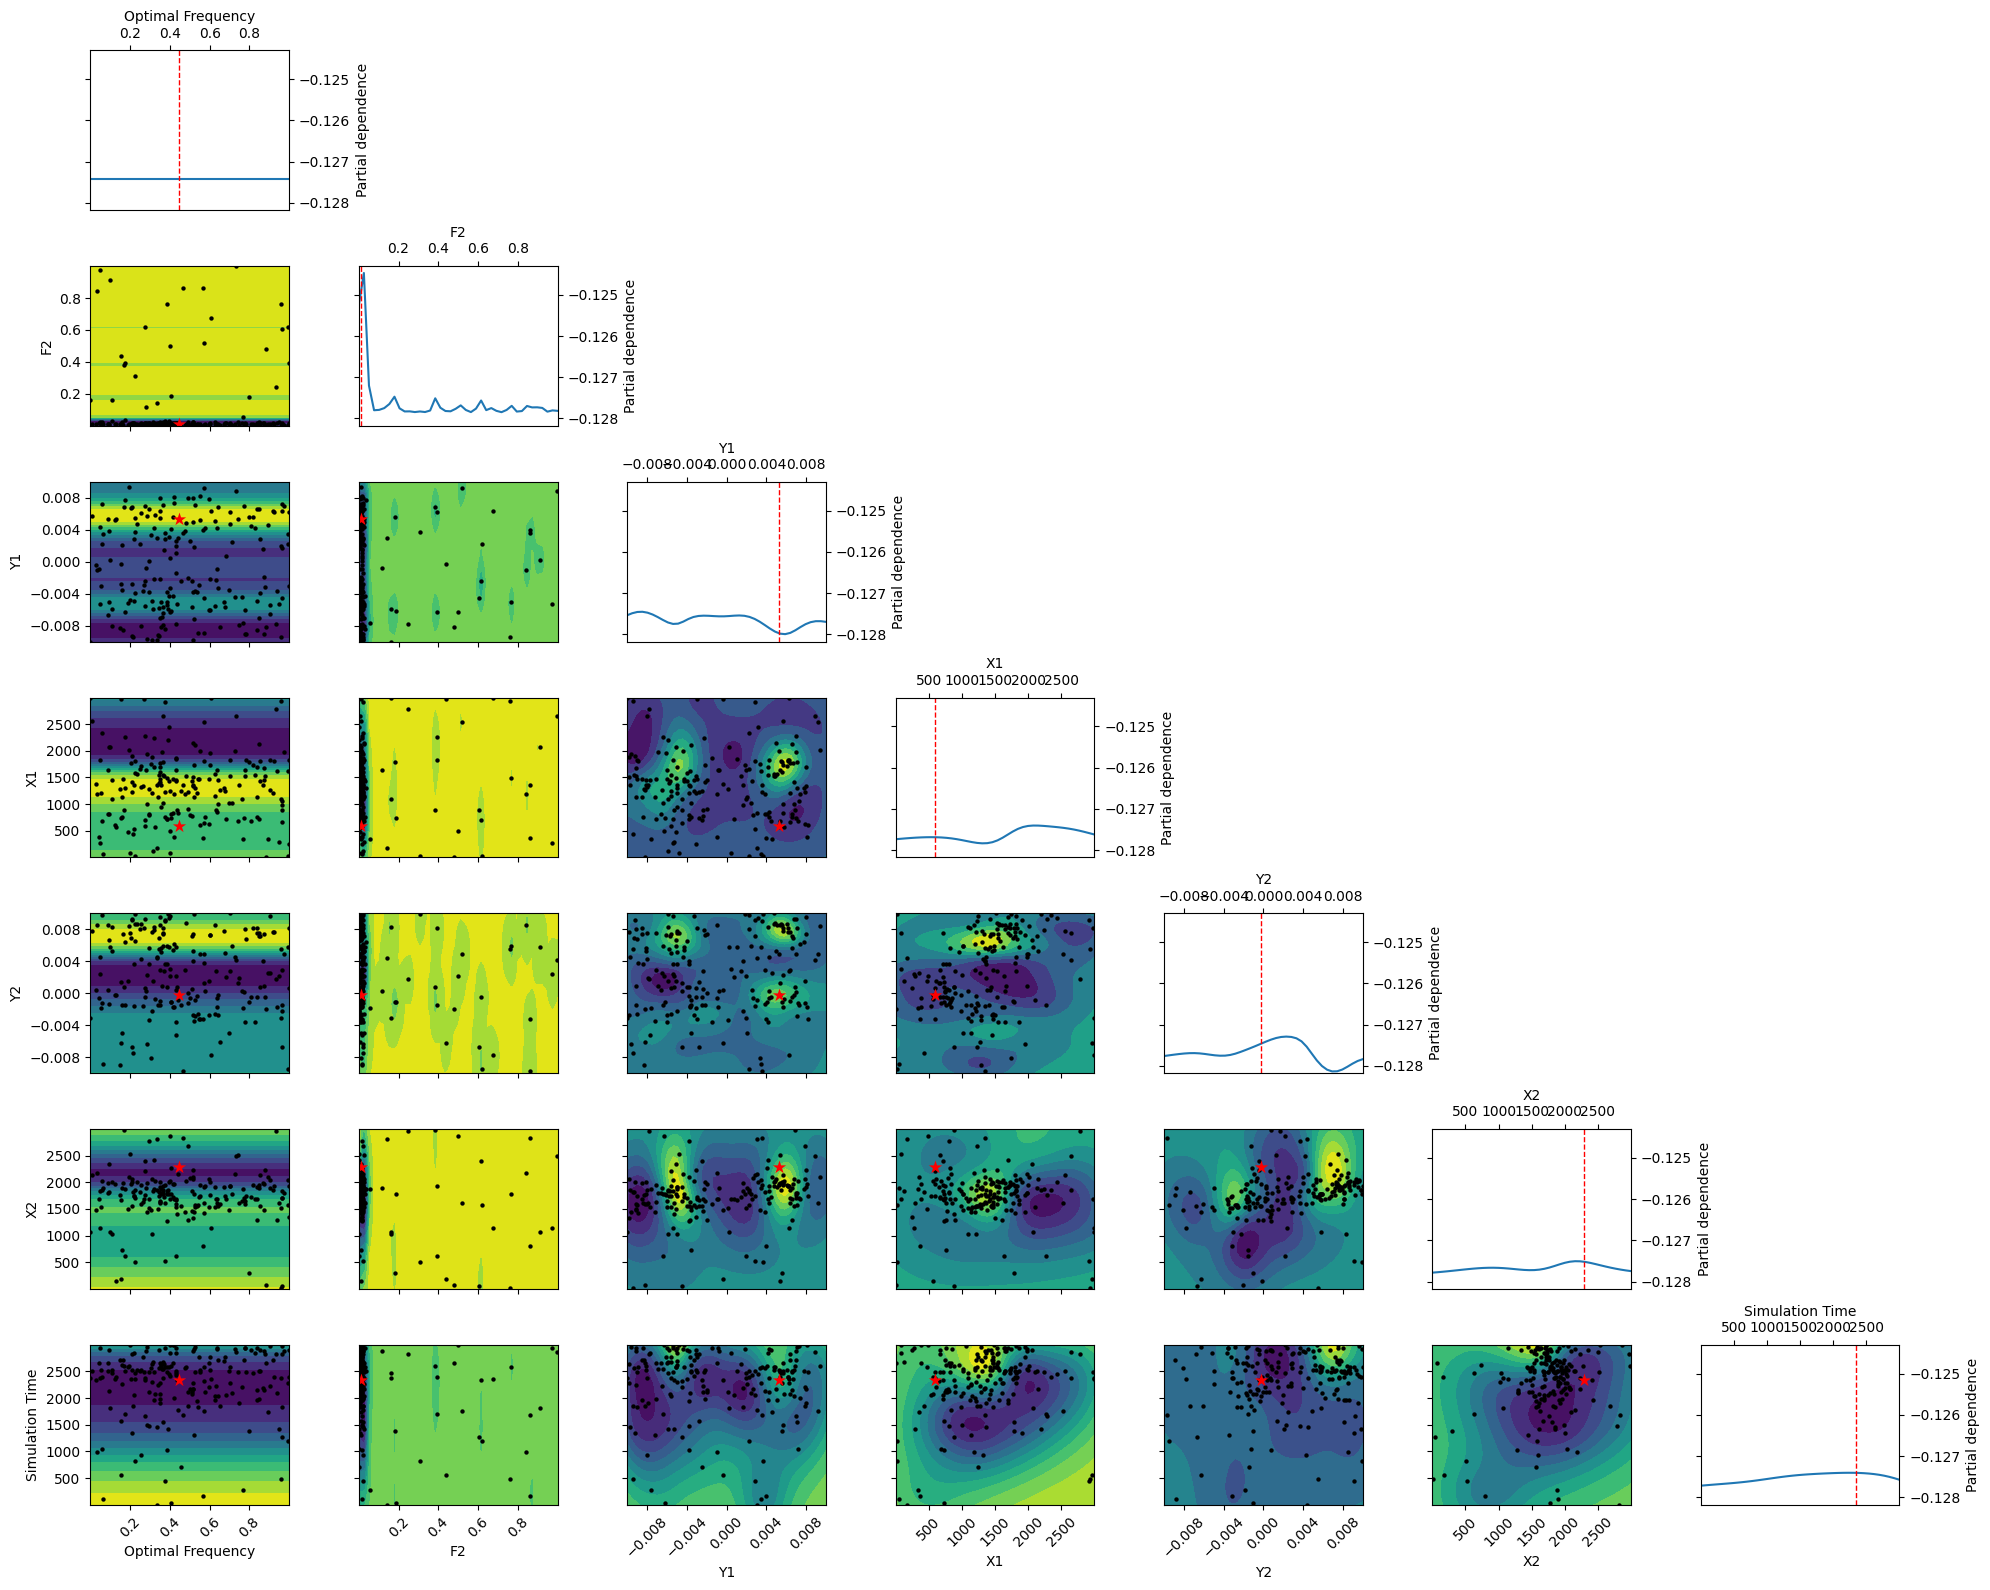

In [44]:
fig, ax = plt.subplots(figsize=(20, 16))  # You can adjust the dimensions as needed
plot_objective(res_alt, dimensions=['Optimal Frequency', 'F2', 'Y1', 'X1', 'Y2', 'X2', 'Simulation Time'], ax=ax)
plt.tight_layout()
plt.show()

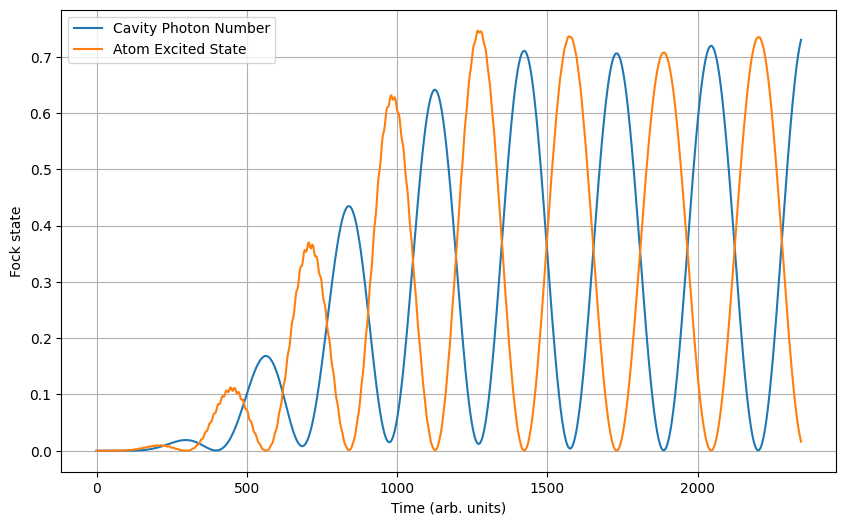

In [45]:
psi = tensor(fock(n_cavity, 0), spin_down)

args = {'frequencies': optimal_frequency, 'f2':optimal_F2, 'spline': spline}

# Time-dependent driving term
H_drive = [0.5 * (sigma_plus + sigma_minus), lambda t, args: f_t_alt(t, args)]
H_static = delta_c * a.dag() * a + 0.5 * delta_a * sigma_z + (g/wc) * (sigma_plus * a + sigma_minus * a.dag())
H = [H_static, H_drive]

output = mesolve(H, psi, tau, c_ops=[], e_ops=[a.dag() * a, sigma_plus * sigma_minus], args=args)

n_c = output.expect[0]
n_a = output.expect[1]


plt.figure(figsize=(10,6))
plt.plot(tau, n_c, label = 'Cavity Photon Number')
plt.plot(tau, n_a, label = 'Atom Excited State')
plt.grid(True)
plt.xlabel('Time (arb. units)')
plt.ylabel('Fock state')
plt.legend(loc='best')
plt.show()